# Olist E-Commerce Data Analysis

Notebook ini sudah dirapikan untuk alur analisis dataset **Olist Brazilian E-Commerce**.

Isi notebook:
1. Load semua file CSV Olist.
2. Validasi relasi ID.
3. Merge semua tabel utama.
4. Tambahkan data lokasi dari geolocation.
5. Data cleaning dan feature engineering.
6. KPI bisnis.
7. Analisis kategori produk.
8. Visualisasi dashboard.
9. Heatmap revenue bulanan.
10. Analisis jarak customer-seller.
11. Business insights dan rekomendasi.

## Deskripsi Alur Data

Dataset Olist terdiri dari beberapa tabel yang saling terhubung memakai ID.

```text
olist_order_items_dataset
        |
        |-- order_id   --> olist_orders_dataset
        |                       |
        |                       |-- customer_id --> olist_customers_dataset
        |
        |-- product_id --> olist_products_dataset
        |                       |
        |                       |-- product_category_name --> product_category_name_translation
        |
        |-- seller_id  --> olist_sellers_dataset
        |
        |-- order_id   --> olist_order_payments_dataset
        |
        |-- order_id   --> olist_order_reviews_dataset
```

Data lokasi ditambahkan melalui ZIP code:

```text
customer_zip_code_prefix --> olist_geolocation_dataset
seller_zip_code_prefix   --> olist_geolocation_dataset
```

Strategi penggabungan:
- Tabel utama dimulai dari `order_items`, karena satu baris merepresentasikan satu item dalam order.
- `payments` dan `reviews` diagregasi per `order_id` supaya tidak menggandakan baris.
- `geolocation` diagregasi per ZIP code supaya merge lokasi tidak membuat jumlah baris membengkak.

## 1. Import Library dan Konfigurasi

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

FIG_COLOR = "#F8F9FA"

print("Library berhasil dimuat.")

Library berhasil dimuat.


## 2. Load Dataset

In [2]:
DATA_DIR = "."

required_files = [
    "olist_customers_dataset.csv",
    "olist_geolocation_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_order_payments_dataset.csv",
    "olist_order_reviews_dataset.csv",
    "olist_orders_dataset.csv",
    "olist_products_dataset.csv",
    "olist_sellers_dataset.csv",
    "product_category_name_translation.csv",
]

missing_files = [
    file for file in required_files
    if not os.path.exists(os.path.join(DATA_DIR, file))
]

if missing_files:
    print("File berikut belum ditemukan:")
    for file in missing_files:
        print("-", file)
else:
    print("Semua file CSV ditemukan.")

Semua file CSV ditemukan.


In [3]:
customers = pd.read_csv(f"{DATA_DIR}/olist_customers_dataset.csv")

orders = pd.read_csv(
    f"{DATA_DIR}/olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)

order_items = pd.read_csv(
    f"{DATA_DIR}/olist_order_items_dataset.csv",
    parse_dates=["shipping_limit_date"],
)

payments = pd.read_csv(f"{DATA_DIR}/olist_order_payments_dataset.csv")

reviews = pd.read_csv(
    f"{DATA_DIR}/olist_order_reviews_dataset.csv",
    parse_dates=["review_creation_date", "review_answer_timestamp"],
)

products = pd.read_csv(f"{DATA_DIR}/olist_products_dataset.csv")
sellers = pd.read_csv(f"{DATA_DIR}/olist_sellers_dataset.csv")
geolocation = pd.read_csv(f"{DATA_DIR}/olist_geolocation_dataset.csv")
category_translation = pd.read_csv(f"{DATA_DIR}/product_category_name_translation.csv")

print("Semua dataset berhasil dimuat.")

Semua dataset berhasil dimuat.


## 3. Validasi Relasi Data

In [4]:
print("=== CEK DUPLICATE PRIMARY KEY ===")
print("Duplicate customer_id:", customers["customer_id"].duplicated().sum())
print("Duplicate order_id:", orders["order_id"].duplicated().sum())
print("Duplicate product_id:", products["product_id"].duplicated().sum())
print("Duplicate seller_id:", sellers["seller_id"].duplicated().sum())
print("Duplicate category translation:", category_translation["product_category_name"].duplicated().sum())

=== CEK DUPLICATE PRIMARY KEY ===
Duplicate customer_id: 0
Duplicate order_id: 0
Duplicate product_id: 0
Duplicate seller_id: 0
Duplicate category translation: 0


In [5]:
print("=== CEK FOREIGN KEY ===")

print("order_items order_id tidak ada di orders:",
      (~order_items["order_id"].isin(orders["order_id"])).sum())

print("orders customer_id tidak ada di customers:",
      (~orders["customer_id"].isin(customers["customer_id"])).sum())

print("order_items product_id tidak ada di products:",
      (~order_items["product_id"].isin(products["product_id"])).sum())

print("order_items seller_id tidak ada di sellers:",
      (~order_items["seller_id"].isin(sellers["seller_id"])).sum())

print("payments order_id tidak ada di orders:",
      (~payments["order_id"].isin(orders["order_id"])).sum())

print("reviews order_id tidak ada di orders:",
      (~reviews["order_id"].isin(orders["order_id"])).sum())

=== CEK FOREIGN KEY ===
order_items order_id tidak ada di orders: 0
orders customer_id tidak ada di customers: 0
order_items product_id tidak ada di products: 0
order_items seller_id tidak ada di sellers: 0
payments order_id tidak ada di orders: 0
reviews order_id tidak ada di orders: 0


## 4. Merge Dataset Utama

In [6]:
# Hindari kolom product_category_name_english_x dan _y jika cell dijalankan ulang
products_clean = products.drop(
    columns=["product_category_name_english"],
    errors="ignore",
)

products_en = products_clean.merge(
    category_translation,
    on="product_category_name",
    how="left",
    validate="many_to_one",
)

# Agregasi payment per order
payments_agg = (
    payments
    .groupby("order_id", as_index=False)
    .agg(
        payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "max"),
        payment_type=("payment_type", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
        n_payments=("payment_sequential", "max"),
    )
)

# Agregasi review per order
reviews_agg = (
    reviews
    .groupby("order_id", as_index=False)
    .agg(
        review_score=("review_score", "mean"),
        review_count=("review_id", "nunique"),
    )
)

jumlah_baris_awal = len(order_items)

df_raw = (
    order_items
    .merge(orders, on="order_id", how="left", validate="many_to_one")
    .merge(customers, on="customer_id", how="left", validate="many_to_one")
    .merge(products_en, on="product_id", how="left", validate="many_to_one")
    .merge(sellers, on="seller_id", how="left", validate="many_to_one")
    .merge(payments_agg, on="order_id", how="left", validate="many_to_one")
    .merge(reviews_agg, on="order_id", how="left", validate="many_to_one")
)

print("Dataset utama berhasil digabung.")
print(f"Order items awal : {jumlah_baris_awal:,}")
print(f"Setelah merge    : {len(df_raw):,}")

if len(df_raw) == jumlah_baris_awal:
    print("Aman: jumlah baris tidak berubah.")
else:
    print("Perhatian: jumlah baris berubah.")

suffix_cols = [col for col in df_raw.columns if col.endswith("_x") or col.endswith("_y")]
print("Kolom _x/_y:", suffix_cols)

df_raw.head()

Dataset utama berhasil digabung.
Order items awal : 112,650
Setelah merge    : 112,650
Aman: jumlah baris tidak berubah.
Kolom _x/_y: []


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,payment_type,n_payments,review_score,review_count
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,cool_stuff,58.00,598.00,4.00,650.00,28.00,9.00,14.00,cool_stuff,27277,volta redonda,SP,72.19,2.00,credit_card,1.00,5.00,1.00
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet_shop,56.00,239.00,2.00,"30,000.00",50.00,30.00,40.00,pet_shop,3471,sao paulo,SP,259.83,3.00,credit_card,1.00,4.00,1.00
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,moveis_decoracao,59.00,695.00,2.00,"3,050.00",33.00,13.00,33.00,furniture_decor,37564,borda da mata,MG,216.87,5.00,credit_card,1.00,5.00,1.00
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,perfumaria,42.00,480.00,1.00,200.00,16.00,10.00,15.00,perfumery,14403,franca,SP,25.78,2.00,credit_card,1.00,4.00,1.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,ferramentas_jardim,59.00,409.00,1.00,"3,750.00",35.00,40.00,30.00,garden_tools,87900,loanda,PR,218.04,3.00,credit_card,1.00,5.00,1.00


## 5. Tambahkan Data Lokasi

In [7]:
# Geolocation diagregasi per ZIP code supaya merge tidak menggandakan baris.
geolocation["zip_key"] = (
    geolocation["geolocation_zip_code_prefix"]
    .astype(str)
    .str.zfill(5)
)

df_raw["customer_zip_key"] = (
    df_raw["customer_zip_code_prefix"]
    .astype(str)
    .str.zfill(5)
)

df_raw["seller_zip_key"] = (
    df_raw["seller_zip_code_prefix"]
    .astype(str)
    .str.zfill(5)
)

geo_agg = (
    geolocation
    .groupby("zip_key", as_index=False)
    .agg(
        geo_lat=("geolocation_lat", "mean"),
        geo_lng=("geolocation_lng", "mean"),
        geo_city=("geolocation_city", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
        geo_state=("geolocation_state", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
    )
)

customer_geo = geo_agg.rename(columns={
    "zip_key": "customer_zip_key",
    "geo_lat": "customer_lat",
    "geo_lng": "customer_lng",
    "geo_city": "customer_geo_city",
    "geo_state": "customer_geo_state",
})

seller_geo = geo_agg.rename(columns={
    "zip_key": "seller_zip_key",
    "geo_lat": "seller_lat",
    "geo_lng": "seller_lng",
    "geo_city": "seller_geo_city",
    "geo_state": "seller_geo_state",
})

jumlah_baris_awal_geo = len(df_raw)

df_raw = (
    df_raw
    .merge(customer_geo, on="customer_zip_key", how="left", validate="many_to_one")
    .merge(seller_geo, on="seller_zip_key", how="left", validate="many_to_one")
)

print("Data lokasi berhasil dimasukkan.")
print(f"Baris sebelum merge lokasi : {jumlah_baris_awal_geo:,}")
print(f"Baris setelah merge lokasi : {len(df_raw):,}")

if len(df_raw) == jumlah_baris_awal_geo:
    print("Aman: jumlah baris tidak berubah.")
else:
    print("Perhatian: jumlah baris berubah.")

print("\n=== CEK MISSING LOKASI ===")
print("Customer lat missing:", df_raw["customer_lat"].isna().sum())
print("Customer lng missing:", df_raw["customer_lng"].isna().sum())
print("Seller lat missing:", df_raw["seller_lat"].isna().sum())
print("Seller lng missing:", df_raw["seller_lng"].isna().sum())

Data lokasi berhasil dimasukkan.
Baris sebelum merge lokasi : 112,650
Baris setelah merge lokasi : 112,650
Aman: jumlah baris tidak berubah.

=== CEK MISSING LOKASI ===
Customer lat missing: 302
Customer lng missing: 302
Seller lat missing: 253
Seller lng missing: 253


In [8]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # radius bumi dalam kilometer

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df_raw["customer_seller_distance_km"] = haversine_distance(
    df_raw["customer_lat"],
    df_raw["customer_lng"],
    df_raw["seller_lat"],
    df_raw["seller_lng"],
)

print("Jarak customer-seller berhasil dihitung.")

df_raw[[
    "customer_state",
    "seller_state",
    "customer_lat",
    "customer_lng",
    "seller_lat",
    "seller_lng",
    "customer_seller_distance_km",
]].head()

Jarak customer-seller berhasil dihitung.


,customer_state,seller_state,customer_lat,customer_lng,seller_lat,seller_lng,customer_seller_distance_km
0,RJ,SP,-21.76,-41.31,-22.50,-44.13,301.50
1,SP,SP,-20.22,-50.90,-23.57,-46.52,585.56
2,MG,MG,-19.87,-44.59,-22.26,-46.17,312.34
3,SP,SP,-23.09,-46.61,-20.55,-47.39,293.17
4,SP,PR,-23.24,-46.83,-22.93,-53.14,646.16


## 6. EDA Awal

In [9]:
print("=== INFO DATASET ===")
df_raw.info()

print("\n=== 5 DATA TERATAS ===")
display(df_raw.head())

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 47 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  object        
 1   order_item_id                  112650 non-null  int64         
 2   product_id                     112650 non-null  object        
 3   seller_id                      112650 non-null  object        
 4   shipping_limit_date            112650 non-null  datetime64[ns]
 5   price                          112650 non-null  float64       
 6   freight_value                  112650 non-null  float64       
 7   customer_id                    112650 non-null  object        
 8   order_status                   112650 non-null  object        
 9   order_purchase_timestamp       112650 non-null  datetime64[ns]
 10  order_approved_at              112635 non-null 

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,payment_type,n_payments,review_score,review_count,customer_zip_key,seller_zip_key,customer_lat,customer_lng,customer_geo_city,customer_geo_state,seller_lat,seller_lng,seller_geo_city,seller_geo_state,customer_seller_distance_km
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,cool_stuff,58.00,598.00,4.00,650.00,28.00,9.00,14.00,cool_stuff,27277,volta redonda,SP,72.19,2.00,credit_card,1.00,5.00,1.00,28013,27277,-21.76,-41.31,campos dos goytacazes,RJ,-22.50,-44.13,volta redonda,RJ,301.50
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet_shop,56.00,239.00,2.00,"30,000.00",50.00,30.00,40.00,pet_shop,3471,sao paulo,SP,259.83,3.00,credit_card,1.00,4.00,1.00,15775,03471,-20.22,-50.90,santa fe do sul,SP,-23.57,-46.52,sao paulo,SP,585.56
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,moveis_decoracao,59.00,695.00,2.00,"3,050.00",33.00,13.00,33.00,furniture_decor,37564,borda da mata,MG,216.87,5.00,credit_card,1.00,5.00,1.00,35661,37564,-19.87,-44.59,para de minas,MG,-22.26,-46.17,borda da mata,MG,312.34
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,perfumaria,42.00,480.00,1.00,200.00,16.00,10.00,15.00,perfumery,14403,franca,SP,25.78,2.00,credit_card,1.00,4.00,1.00,12952,14403,-23.09,-46.61,atibaia,SP,-20.55,-47.39,franca,SP,293.17
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,ferramentas_jardim,59.00,409.00,1.00,"3,750.00",35.00,40.00,30.00,garden_tools,87900,loanda,PR,218.04,3.00,credit_card,1.00,5.00,1.00,13226,87900,-23.24,-46.83,varzea paulista,SP,-22.93,-53.14,loanda,PR,646.16


In [10]:
print("=== STATISTIK DESKRIPTIF ===")
display(df_raw.describe().round(2))

=== STATISTIK DESKRIPTIF ===


,order_item_id,shipping_limit_date,price,freight_value,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,payment_value,payment_installments,n_payments,review_score,review_count,customer_lat,customer_lng,seller_lat,seller_lng,customer_seller_distance_km
count,"112,650.00",112650,"112,650.00","112,650.00",112650,112635,111456,110196,112650,"112,650.00","111,047.00","111,047.00","111,047.00","112,632.00","112,632.00","112,632.00","112,632.00","112,650.00","112,647.00","112,647.00","112,647.00","111,708.00","111,708.00","112,348.00","112,348.00","112,397.00","112,397.00","112,096.00"
mean,1.20,2018-01-07 15:36:52.192685312,120.65,19.99,2018-01-01 00:09:48.464376576,2018-01-01 11:46:01.497003776,2018-01-05 02:22:56.161642240,2018-01-14 13:25:24.023939328,2018-01-24 20:12:15.531291392,"35,119.31",48.78,787.87,2.21,"2,093.67",30.15,16.59,23.00,"24,439.17",180.28,3.02,1.04,4.03,1.01,-21.23,-46.20,-22.80,-47.24,596.96
min,1.00,2016-09-19 00:15:34,0.85,0.00,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,"1,003.00",5.00,4.00,1.00,0.00,7.00,2.00,6.00,"1,001.00",9.59,0.00,1.00,1.00,1.00,-33.69,-72.67,-32.08,-67.81,0.00
25%,1.00,2017-09-20 20:57:27.500000,39.90,13.08,2017-09-13 19:17:04,2017-09-14 03:06:05,2017-09-18 20:41:02.249999872,2017-09-26 20:09:44.500000,2017-10-05 00:00:00,"11,310.00",42.00,348.00,1.00,300.00,18.00,8.00,15.00,"6,429.00",65.67,1.00,1.00,4.00,1.00,-23.59,-48.11,-23.61,-48.83,184.07
50%,1.00,2018-01-26 13:59:35,74.99,16.26,2018-01-19 23:02:16,2018-01-20 13:42:05,2018-01-24 18:44:52.500000,2018-02-02 20:57:23,2018-02-16 00:00:00,"24,340.00",52.00,603.00,1.00,700.00,25.00,13.00,20.00,"13,568.00",114.44,2.00,1.00,5.00,1.00,-22.93,-46.63,-23.43,-46.74,431.64
75%,1.00,2018-05-10 14:34:00.750000128,134.90,21.15,2018-05-04 17:30:36.750000128,2018-05-05 03:10:16.500000,2018-05-08 13:20:15,2018-05-15 20:09:21.500000,2018-05-28 00:00:00,"59,028.75",57.00,987.00,3.00,"1,800.00",38.00,20.00,30.00,"27,930.00",195.39,4.00,1.00,5.00,1.00,-20.17,-43.64,-21.76,-46.52,792.28
max,21.00,2020-04-09 22:35:08,"6,735.00",409.68,2018-09-03 09:06:57,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,"99,990.00",76.00,"3,992.00",20.00,"40,425.00",105.00,105.00,118.00,"99,730.00","13,664.08",24.00,29.00,5.00,3.00,42.18,-8.72,-2.50,-34.86,"8,677.91"
std,0.71,NaN,183.63,15.81,NaN,NaN,NaN,NaN,NaN,"29,866.12",10.03,652.14,1.72,"3,751.60",16.15,13.44,11.71,"27,596.03",272.85,2.80,0.39,1.39,0.08,5.57,4.04,2.70,2.34,589.98


In [11]:
print("=== MISSING VALUES ===")

missing = df_raw.isnull().sum()
pct = (missing / len(df_raw) * 100).round(2)

missing_table = pd.DataFrame({
    "Count": missing,
    "Pct %": pct,
}).loc[missing > 0].sort_values("Count", ascending=False)

display(missing_table)

=== MISSING VALUES ===


,Count,Pct %
order_delivered_customer_date,2454,2.18
product_category_name_english,1627,1.44
product_name_lenght,1603,1.42
product_description_lenght,1603,1.42
product_photos_qty,1603,1.42
product_category_name,1603,1.42
order_delivered_carrier_date,1194,1.06
review_score,942,0.84
review_count,942,0.84
customer_seller_distance_km,554,0.49


In [12]:
categorical_cols = [
    "order_status",
    "product_category_name_english",
    "customer_state",
    "seller_state",
    "payment_type",
]

for col in categorical_cols:
    if col in df_raw.columns:
        print(f"\n=== {col} ===")
        print(df_raw[col].value_counts(dropna=False).head(10))


=== order_status ===
order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64

=== product_category_name_english ===
product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: count, dtype: int64

=== customer_state ===
customer_state
SP    47449
RJ    14579
MG    13129
RS     6235
PR     5740
SC     4176
BA     3799
DF     2406
GO     2333
ES     2256
Name: count, dtype: int64

=== seller_state ===
seller_state
SP    80342
MG     8827
PR     8671
RJ     4818
SC     4075
RS     2199
DF      899
BA      643
GO      520
PE      448
Name: count, dtype: int64

=== payment_t

## 7. Data Cleaning dan Feature Engineering

In [13]:
df = df_raw.copy()

# Hapus kolom fitur lama jika sudah pernah dibuat sebelumnya
old_feature_cols = [
    "total_item_value",
    "order_year",
    "order_month",
    "order_month_name",
    "estimated_delivery_days",
    "delivery_days",
    "delivery_delay_days",
]

df = df.drop(
    columns=[col for col in old_feature_cols if col in df.columns],
    errors="ignore",
)

# Ambil hanya order yang sudah delivered
df = df[df["order_status"] == "delivered"].copy()

# Drop missing values di kolom kritis
df = df.dropna(subset=[
    "order_id",
    "product_id",
    "seller_id",
    "customer_id",
    "price",
    "freight_value",
    "order_purchase_timestamp",
])

# Fix tipe data tanggal
date_cols = [
    "shipping_limit_date",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Drop missing kecil pada tanggal penting
df = df.dropna(subset=[
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
])

# Isi missing kategori dan kota
df["product_category_name"] = df["product_category_name"].fillna("unknown")
df["product_category_name_english"] = df["product_category_name_english"].fillna("unknown")
df["customer_city"] = df["customer_city"].fillna("Unknown")
df["seller_city"] = df["seller_city"].fillna("Unknown")

# Drop payment kosong
df = df.dropna(subset=[
    "payment_value",
    "payment_installments",
    "payment_type",
    "n_payments",
])

# Review kosong tidak diisi 0 karena skor valid adalah 1-5
df["has_review"] = df["review_score"].notna()
df["review_count"] = df["review_count"].fillna(0)

# Isi missing atribut produk numerik
product_numeric_cols = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
]

for col in product_numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Drop data tanpa koordinat lokasi
geo_critical_cols = [
    "customer_lat",
    "customer_lng",
    "seller_lat",
    "seller_lng",
    "customer_seller_distance_km",
]

df = df.dropna(subset=geo_critical_cols)

# Remove duplicates
df = df.drop_duplicates()

# ZIP code lebih cocok sebagai string
df["customer_zip_code_prefix"] = df["customer_zip_code_prefix"].astype(str)
df["seller_zip_code_prefix"] = df["seller_zip_code_prefix"].astype(str)

# Feature engineering
df["Total_Item_Value"] = df["price"] + df["freight_value"]

df["Year"] = df["order_purchase_timestamp"].dt.year
df["Month"] = df["order_purchase_timestamp"].dt.month
df["Month_Name"] = df["order_purchase_timestamp"].dt.strftime("%b")
df["Quarter"] = df["order_purchase_timestamp"].dt.quarter.map({
    1: "Q1",
    2: "Q2",
    3: "Q3",
    4: "Q4",
})

df["Delivery_Duration"] = (
    df["order_delivered_customer_date"]
    - df["order_purchase_timestamp"]
).dt.days

df["Estimated_Delivery_Duration"] = (
    df["order_estimated_delivery_date"]
    - df["order_purchase_timestamp"]
).dt.days

df["Delivery_Delay"] = (
    df["order_delivered_customer_date"]
    - df["order_estimated_delivery_date"]
).dt.days

df["Is_Late"] = df["Delivery_Delay"] > 0

df = df.reset_index(drop=True)

print(f"Data bersih: {df.shape[0]:,} baris × {df.shape[1]} kolom")
df.head()

Data bersih: 109,634 baris × 57 kolom


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,payment_type,n_payments,review_score,review_count,customer_zip_key,seller_zip_key,customer_lat,customer_lng,customer_geo_city,customer_geo_state,seller_lat,seller_lng,seller_geo_city,seller_geo_state,customer_seller_distance_km,has_review,Total_Item_Value,Year,Month,Month_Name,Quarter,Delivery_Duration,Estimated_Delivery_Duration,Delivery_Delay,Is_Late
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,cool_stuff,58.00,598.00,4.00,650.00,28.00,9.00,14.00,cool_stuff,27277,volta redonda,SP,72.19,2.00,credit_card,1.00,5.00,1.00,28013,27277,-21.76,-41.31,campos dos goytacazes,RJ,-22.50,-44.13,volta redonda,RJ,301.50,True,72.19,2017,9,Sep,Q3,7,15,-9,False
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet_shop,56.00,239.00,2.00,"30,000.00",50.00,30.00,40.00,pet_shop,3471,sao paulo,SP,259.83,3.00,credit_card,1.00,4.00,1.00,15775,03471,-20.22,-50.90,santa fe do sul,SP,-23.57,-46.52,sao paulo,SP,585.56,True,259.83,2017,4,Apr,Q2,16,18,-3,False
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,moveis_decoracao,59.00,695.00,2.00,"3,050.00",33.00,13.00,33.00,furniture_decor,37564,borda da mata,MG,216.87,5.00,credit_card,1.00,5.00,1.00,35661,37564,-19.87,-44.59,para de minas,MG,-22.26,-46.17,borda da mata,MG,312.34,True,216.87,2018,1,Jan,Q1,7,21,-14,False
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,perfumaria,42.00,480.00,1.00,200.00,16.00,10.00,15.00,perfumery,14403,franca,SP,25.78,2.00,credit_card,1.00,4.00,1.00,12952,14403,-23.09,-46.61,atibaia,SP,-20.55,-47.39,franca,SP,293.17,True,25.78,2018,8,Aug,Q3,6,11,-6,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,ferramentas_jardim,59.00,409.00,1.00,"3,750.00",35.00,40.00,30.00,garden_tools,87900,loanda,PR,218.04,3.00,credit_card,1.00,5.00,1.00,13226,87900,-23.24,-46.83,varzea paulista,SP,-22.93,-53.14,loanda,PR,646.16,True,218.04,2017,2,Feb,Q1,25,40,-16,False


In [14]:
print("=== MISSING VALUES AFTER CLEANING ===")

missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Count": missing,
    "Pct %": pct,
}).loc[missing > 0].sort_values("Count", ascending=False)

display(missing_table)

print("\nDuplicate rows:", df.duplicated().sum())

print("\n=== INFO DATA CLEAN ===")
df.info()

=== MISSING VALUES AFTER CLEANING ===


,Count,Pct %
review_score,826,0.75



Duplicate rows: 0

=== INFO DATA CLEAN ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109634 entries, 0 to 109633
Data columns (total 57 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       109634 non-null  object        
 1   order_item_id                  109634 non-null  int64         
 2   product_id                     109634 non-null  object        
 3   seller_id                      109634 non-null  object        
 4   shipping_limit_date            109634 non-null  datetime64[ns]
 5   price                          109634 non-null  float64       
 6   freight_value                  109634 non-null  float64       
 7   customer_id                    109634 non-null  object        
 8   order_status                   109634 non-null  object        
 9   order_purchase_timestamp       109634 non-null  datetime64[ns]
 10  order_approved_at       

In [15]:
df.to_csv("olist_clean.csv", index=False)
print("Data bersih berhasil disimpan sebagai olist_clean.csv")

Data bersih berhasil disimpan sebagai olist_clean.csv


## 8. KPI Summary

In [16]:
total_product_revenue = df["price"].sum()
total_freight = df["freight_value"].sum()
total_revenue = df["Total_Item_Value"].sum()

total_orders = df["order_id"].nunique()
total_customers = df["customer_unique_id"].nunique()
total_sellers = df["seller_id"].nunique()
total_products = df["product_id"].nunique()

avg_order_val = df.groupby("order_id")["Total_Item_Value"].sum().mean()
avg_review_score = df["review_score"].mean()
review_rate = df["has_review"].mean() * 100
late_delivery_rate = df["Is_Late"].mean() * 100
avg_distance = df["customer_seller_distance_km"].mean()

kpi = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Product Revenue",
        "Total Freight",
        "Total Orders",
        "Total Customers",
        "Total Sellers",
        "Total Products",
        "Avg Order Value",
        "Avg Review Score",
        "Review Rate",
        "Late Delivery Rate",
        "Avg Customer-Seller Distance",
    ],
    "Value": [
        f"R$ {total_revenue:,.2f}",
        f"R$ {total_product_revenue:,.2f}",
        f"R$ {total_freight:,.2f}",
        f"{total_orders:,}",
        f"{total_customers:,}",
        f"{total_sellers:,}",
        f"{total_products:,}",
        f"R$ {avg_order_val:,.2f}",
        f"{avg_review_score:.2f}",
        f"{review_rate:.1f}%",
        f"{late_delivery_rate:.1f}%",
        f"{avg_distance:,.1f} km",
    ],
})

kpi

,KPI,Value
0,Total Revenue,"R$ 15,343,094.51"
1,Product Revenue,"R$ 13,156,825.56"
2,Total Freight,"R$ 2,186,268.95"
3,Total Orders,"95,978"
4,Total Customers,"92,882"
5,Total Sellers,"2,963"
6,Total Products,"32,105"
7,Avg Order Value,R$ 159.86
8,Avg Review Score,4.08
9,Review Rate,99.2%


## 9. Analisis Kategori Produk

In [17]:
sales_by_cat = (
    df.groupby("product_category_name_english")
    .agg(
        Total_Revenue=("Total_Item_Value", "sum"),
        Product_Revenue=("price", "sum"),
        Total_Freight=("freight_value", "sum"),
        Num_Orders=("order_id", "nunique"),
        Num_Items=("order_item_id", "count"),
        Avg_Review=("review_score", "mean"),
        Late_Rate=("Is_Late", "mean"),
        Avg_Distance_KM=("customer_seller_distance_km", "mean"),
    )
    .sort_values("Total_Revenue", ascending=False)
)

sales_by_cat["Late_Rate_%"] = (sales_by_cat["Late_Rate"] * 100).round(1)
sales_by_cat["Avg_Review"] = sales_by_cat["Avg_Review"].round(2)
sales_by_cat["Avg_Distance_KM"] = sales_by_cat["Avg_Distance_KM"].round(1)
sales_by_cat = sales_by_cat.drop(columns="Late_Rate")

top_cat_revenue = sales_by_cat.head(10)
display(top_cat_revenue)

,Total_Revenue,Product_Revenue,Total_Freight,Num_Orders,Num_Items,Avg_Review,Avg_Distance_KM,Late_Rate_%
product_category_name_english,,,,,,,,
health_beauty,"1,409,051.48","1,230,587.11","178,464.37",8619,9435,4.19,666.50,7.50
watches_gifts,"1,257,778.06","1,160,119.98","97,658.08",5472,5835,4.07,642.40,7.20
bed_bath_table,"1,222,508.62","1,021,331.38","201,177.24",9254,10925,3.92,511.10,7.00
sports_leisure,"1,116,536.66","953,504.76","163,031.90",7512,8412,4.16,595.50,6.30
computers_accessories,"1,027,573.87","884,084.22","143,489.65",6513,7622,3.99,675.50,6.50
furniture_decor,"877,832.19","709,972.64","167,859.55",6286,8137,3.95,561.20,7.00
housewares,"756,440.29","614,011.71","142,428.58",5726,6777,4.11,495.40,5.00
cool_stuff,"683,356.04","603,336.77","80,019.27",3515,3671,4.20,652.90,5.80
auto,"667,952.63","577,637.44","90,315.19",3800,4130,4.12,620.60,7.00


In [18]:
reliable_cat = sales_by_cat[sales_by_cat["Num_Orders"] >= 100].copy()

print("Jumlah kategori reliable:", reliable_cat.shape[0])

print("\n=== TOP 10 LATE DELIVERY RATE TERTINGGI ===")
display(reliable_cat.sort_values("Late_Rate_%", ascending=False).head(10))

print("\n=== TOP 10 AVG REVIEW TERBAIK ===")
display(reliable_cat.sort_values("Avg_Review", ascending=False).head(10))

Jumlah kategori reliable: 52

=== TOP 10 LATE DELIVERY RATE TERTINGGI ===


,Total_Revenue,Product_Revenue,Total_Freight,Num_Orders,Num_Items,Avg_Review,Avg_Distance_KM,Late_Rate_%
product_category_name_english,,,,,,,,
audio,"56,225.19","50,555.70","5,669.49",347,361,3.84,555.50,11.60
christmas_supplies,"11,928.75","8,737.84","3,190.91",125,150,4.07,721.10,10.00
fashion_underwear_beach,"11,160.02","9,305.95","1,854.07",117,127,4.05,548.50,9.40
home_confort,"66,438.22","58,008.45","8,429.77",392,429,3.85,539.40,9.30
books_technical,"22,901.07","18,702.23","4,198.84",256,263,4.39,543.30,8.00
office_furniture,"334,123.30","267,360.52","66,762.78",1248,1662,3.51,558.80,7.90
baby,"464,980.39","398,947.27","66,033.12",2800,2973,4.08,598.30,7.70
health_beauty,"1,409,051.48","1,230,587.11","178,464.37",8619,9435,4.19,666.50,7.50
unknown,"202,696.99","175,417.60","27,279.39",1405,1552,3.93,563.80,7.50



=== TOP 10 AVG REVIEW TERBAIK ===


,Total_Revenue,Product_Revenue,Total_Freight,Num_Orders,Num_Items,Avg_Review,Avg_Distance_KM,Late_Rate_%
product_category_name_english,,,,,,,,
books_general_interest,"54,096.89","45,241.13","8,855.76",494,535,4.51,583.00,6.20
books_technical,"22,901.07","18,702.23","4,198.84",256,263,4.39,543.30,8.00
food_drink,"19,337.77","14,942.88","4,394.89",221,269,4.37,526.30,4.10
luggage_accessories,"168,088.07","138,230.74","29,857.33",1015,1073,4.35,556.30,4.10
fashion_shoes,"27,596.48","22,801.76","4,794.72",234,256,4.29,728.80,4.30
food,"35,528.10","28,525.45","7,002.65",438,496,4.26,450.80,7.10
stationery,"267,655.63","222,175.49","45,480.14",2250,2451,4.24,561.00,6.80
small_appliances,"197,759.46","182,444.22","15,315.24",608,657,4.23,548.90,4.60
home_appliances,"93,067.02","78,672.04","14,394.98",743,750,4.22,550.50,4.50


## 10. Dashboard Visualisasi

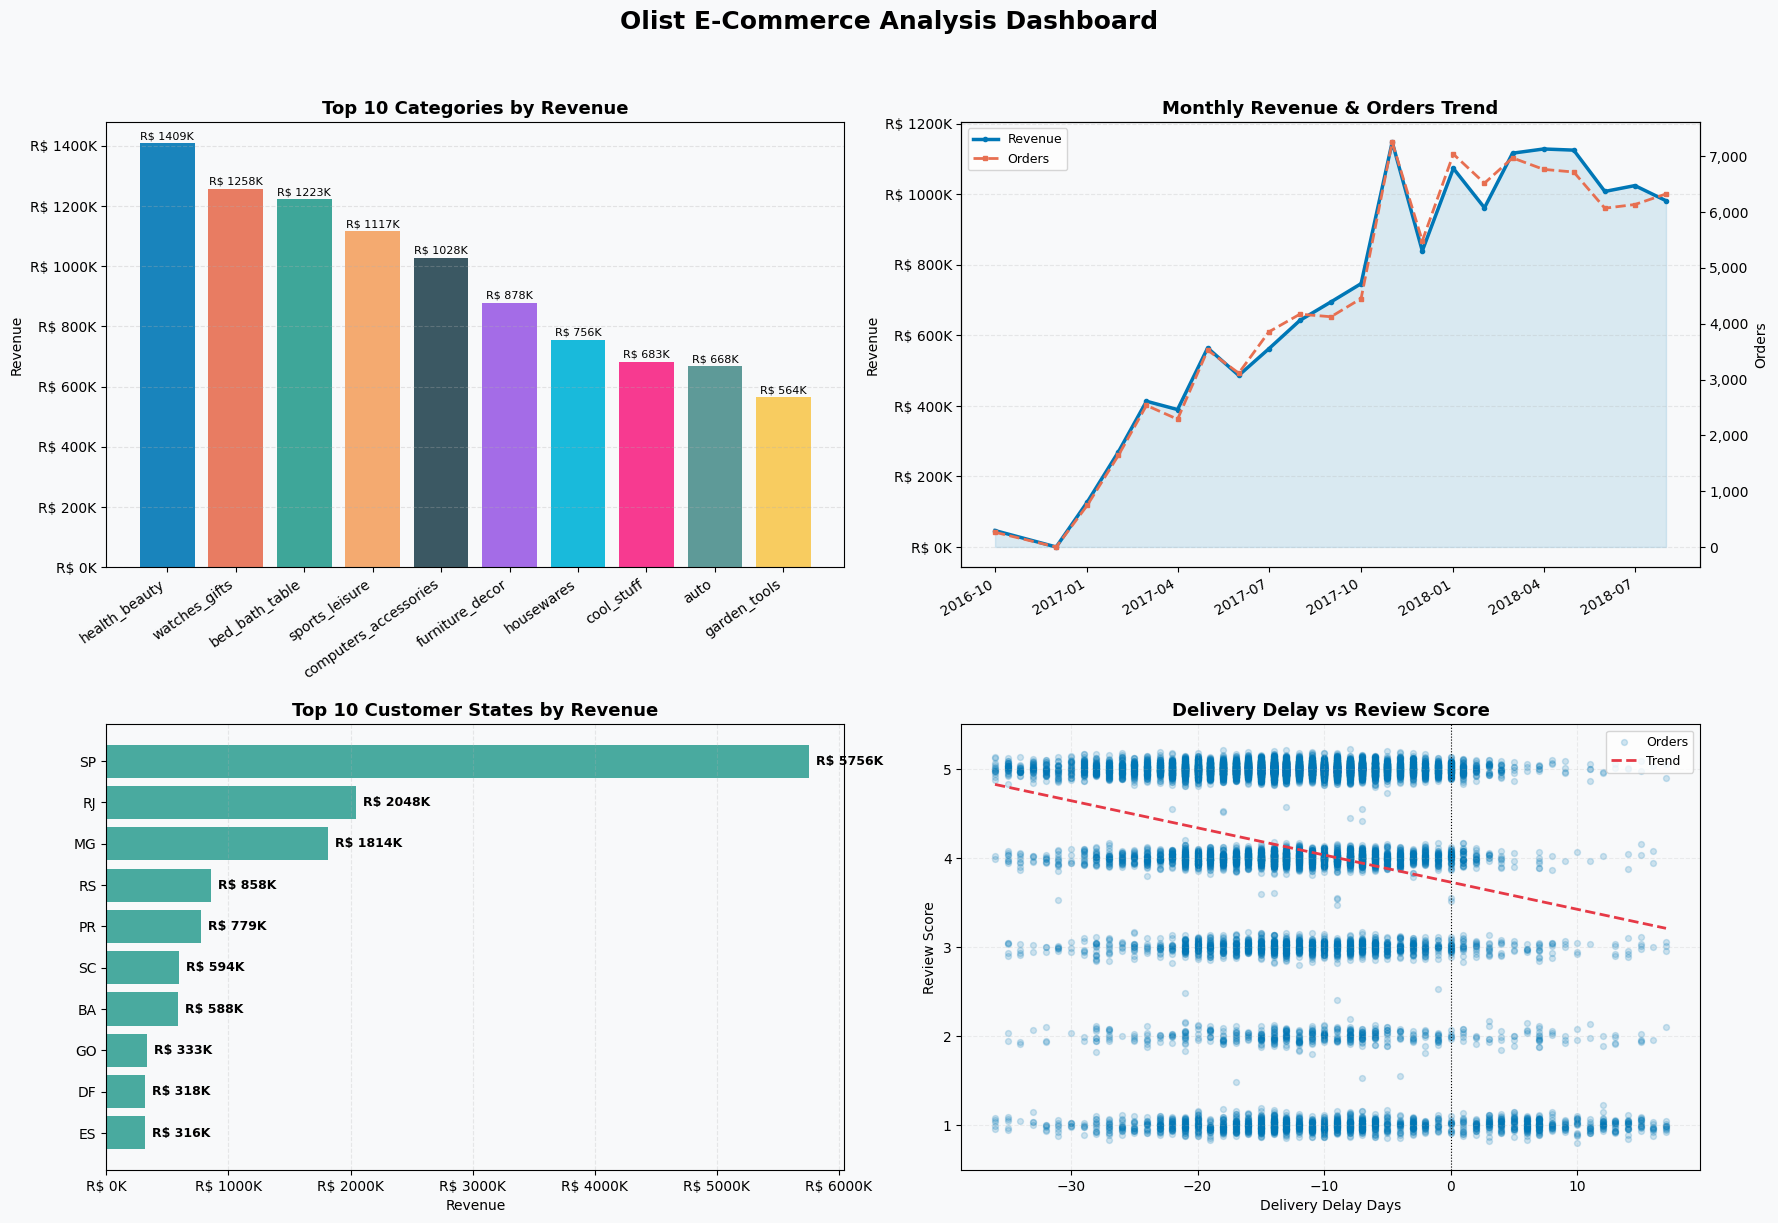

Dashboard disimpan ke olist_dashboard_charts.png


In [19]:
PALETTE = [
    "#0077B6", "#E76F51", "#2A9D8F", "#F4A261", "#264653",
    "#9B5DE5", "#00B4D8", "#F72585", "#4D908E", "#F9C74F",
]

top_cat = sales_by_cat.sort_values("Total_Revenue", ascending=False).head(10).copy()

monthly = (
    df.groupby(["Year", "Month"])
    .agg(
        Revenue=("Total_Item_Value", "sum"),
        Product_Revenue=("price", "sum"),
        Freight=("freight_value", "sum"),
        Orders=("order_id", "nunique"),
    )
    .reset_index()
)

monthly["Date"] = pd.to_datetime(monthly[["Year", "Month"]].assign(Day=1))
monthly = monthly.sort_values("Date")

state_perf = (
    df.groupby("customer_state")
    .agg(
        Revenue=("Total_Item_Value", "sum"),
        Orders=("order_id", "nunique"),
        Late_Rate=("Is_Late", "mean"),
    )
    .sort_values("Revenue", ascending=False)
    .head(10)
)

state_perf["Late_Rate_%"] = state_perf["Late_Rate"] * 100

review_delivery = df.dropna(subset=["review_score", "Delivery_Delay"]).copy()
lower = review_delivery["Delivery_Delay"].quantile(0.01)
upper = review_delivery["Delivery_Delay"].quantile(0.99)

review_delivery = review_delivery[
    review_delivery["Delivery_Delay"].between(lower, upper)
].copy()

np.random.seed(42)
review_delivery["review_score_jitter"] = (
    review_delivery["review_score"]
    + np.random.normal(0, 0.06, len(review_delivery))
)

if len(review_delivery) > 15000:
    review_delivery = review_delivery.sample(15000, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor(FIG_COLOR)
fig.suptitle("Olist E-Commerce Analysis Dashboard", fontsize=18, fontweight="bold", y=1.02)

# Chart 1 — Top Categories
ax1 = axes[0, 0]
ax1.set_facecolor(FIG_COLOR)

cats = top_cat.index.tolist()
x = np.arange(len(cats))

bars1 = ax1.bar(x, top_cat["Total_Revenue"] / 1e3, color=PALETTE[:len(cats)], alpha=0.9)

ax1.set_xticks(x)
ax1.set_xticklabels(cats, rotation=35, ha="right")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:.0f}K"))
ax1.set_title("Top 10 Categories by Revenue", fontsize=13, fontweight="bold")
ax1.set_ylabel("Revenue")
ax1.grid(axis="y", alpha=0.3, linestyle="--")

for bar in bars1:
    h = bar.get_height()
    ax1.annotate(
        f"R$ {h:.0f}K",
        xy=(bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        fontsize=8,
    )

# Chart 2 — Monthly Trend
ax2 = axes[0, 1]
ax2.set_facecolor(FIG_COLOR)

ax2.plot(
    monthly["Date"], monthly["Revenue"] / 1e3,
    color="#0077B6", linewidth=2.5, marker="o", markersize=3, label="Revenue"
)
ax2.fill_between(monthly["Date"], monthly["Revenue"] / 1e3, alpha=0.12, color="#0077B6")

ax2b = ax2.twinx()
ax2b.plot(
    monthly["Date"], monthly["Orders"],
    color="#E76F51", linewidth=2, linestyle="--", marker="s", markersize=3, label="Orders"
)

ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:.0f}K"))
ax2b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax2.set_title("Monthly Revenue & Orders Trend", fontsize=13, fontweight="bold")
ax2.set_ylabel("Revenue")
ax2b.set_ylabel("Orders")
ax2.grid(axis="y", alpha=0.25, linestyle="--")

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")
plt.setp(ax2.get_xticklabels(), rotation=30, ha="right")

# Chart 3 — Customer States
ax3 = axes[1, 0]
ax3.set_facecolor(FIG_COLOR)

state_sorted = state_perf.sort_values("Revenue", ascending=True)
bars3 = ax3.barh(state_sorted.index, state_sorted["Revenue"] / 1e3, color="#2A9D8F", alpha=0.85)

ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:.0f}K"))
ax3.set_title("Top 10 Customer States by Revenue", fontsize=13, fontweight="bold")
ax3.set_xlabel("Revenue")
ax3.grid(axis="x", alpha=0.25, linestyle="--")

for bar in bars3:
    w = bar.get_width()
    ax3.annotate(
        f"R$ {w:.0f}K",
        xy=(w, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        fontsize=9,
        fontweight="bold",
    )

# Chart 4 — Delivery Delay vs Review Score
ax4 = axes[1, 1]
ax4.set_facecolor(FIG_COLOR)

ax4.scatter(
    review_delivery["Delivery_Delay"],
    review_delivery["review_score_jitter"],
    alpha=0.18,
    s=18,
    color="#0077B6",
    label="Orders",
)

x_vals = review_delivery["Delivery_Delay"].values
y_vals = review_delivery["review_score"].values

if len(review_delivery) > 1:
    coef = np.polyfit(x_vals, y_vals, 1)
    x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
    y_line = coef[0] * x_line + coef[1]
    ax4.plot(x_line, y_line, color="#E63946", linewidth=2, linestyle="--", label="Trend")

ax4.axvline(0, color="black", linewidth=0.8, linestyle=":")
ax4.set_title("Delivery Delay vs Review Score", fontsize=13, fontweight="bold")
ax4.set_xlabel("Delivery Delay Days")
ax4.set_ylabel("Review Score")
ax4.set_ylim(0.5, 5.5)
ax4.grid(alpha=0.2, linestyle="--")
ax4.legend(fontsize=9)

plt.tight_layout(pad=1.5)
plt.savefig("olist_dashboard_charts.png", bbox_inches="tight", dpi=150, facecolor=FIG_COLOR)
plt.show()

print("Dashboard disimpan ke olist_dashboard_charts.png")

## 11. Heatmap Revenue Bulanan per Kategori

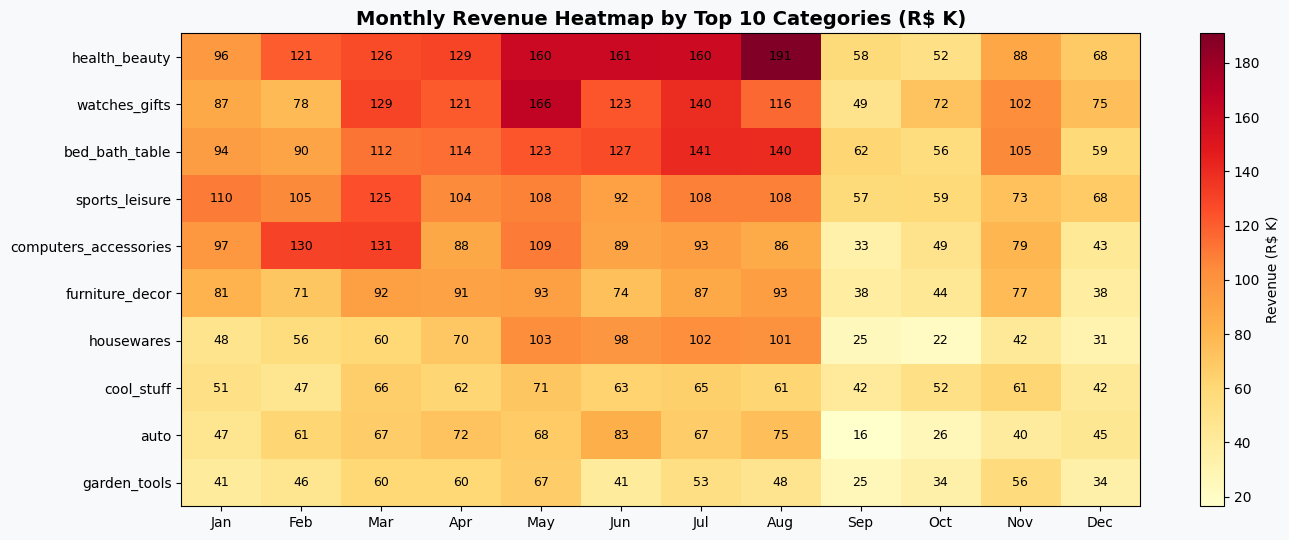

Heatmap disimpan ke heatmap_revenue_by_category.png


In [20]:
fig_h, ax_h = plt.subplots(figsize=(14, 5.5))
fig_h.patch.set_facecolor(FIG_COLOR)
ax_h.set_facecolor(FIG_COLOR)

top_categories = (
    df.groupby("product_category_name_english")["Total_Item_Value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

df_top_cat = df[df["product_category_name_english"].isin(top_categories)].copy()

hm = df_top_cat.pivot_table(
    values="Total_Item_Value",
    index="product_category_name_english",
    columns="Month_Name",
    aggfunc="sum",
)

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

hm = hm.reindex(columns=[m for m in month_order if m in hm.columns])
hm = hm.loc[top_categories]

heatmap_data = hm / 1e3

im = ax_h.imshow(heatmap_data.values, aspect="auto", cmap="YlOrRd")

ax_h.set_xticks(np.arange(len(heatmap_data.columns)))
ax_h.set_xticklabels(heatmap_data.columns)
ax_h.set_yticks(np.arange(len(heatmap_data.index)))
ax_h.set_yticklabels(heatmap_data.index)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        if pd.notna(value):
            ax_h.text(j, i, f"{value:.0f}", ha="center", va="center", fontsize=9)

cbar = fig_h.colorbar(im, ax=ax_h)
cbar.set_label("Revenue (R$ K)")

ax_h.set_title("Monthly Revenue Heatmap by Top 10 Categories (R$ K)", fontsize=14, fontweight="bold")
ax_h.set_xlabel("")
ax_h.set_ylabel("")

plt.tight_layout()
plt.savefig("heatmap_revenue_by_category.png", bbox_inches="tight", dpi=150, facecolor=FIG_COLOR)
plt.show()

print("Heatmap disimpan ke heatmap_revenue_by_category.png")

## 12. Analisis Jarak, Ongkir, dan Delivery

In [21]:
distance_summary = df[[
    "customer_seller_distance_km",
    "freight_value",
    "Delivery_Duration",
    "Delivery_Delay",
    "Is_Late",
    "review_score",
]].describe().round(2)

distance_summary

,customer_seller_distance_km,freight_value,Delivery_Duration,Delivery_Delay,review_score
count,"109,634.00","109,634.00","109,634.00","109,634.00","108,808.00"
mean,596.25,19.94,12.00,-12.03,4.08
std,588.55,15.71,9.45,10.16,1.35
min,0.00,0.00,0.00,-147.00,1.00
25%,185.19,13.07,6.00,-17.00,4.00
50%,431.91,16.25,10.00,-13.00,5.00
75%,791.64,21.15,15.00,-7.00,5.00
max,"8,677.91",409.68,209.00,188.00,5.00


In [22]:
distance_bins = pd.cut(
    df["customer_seller_distance_km"],
    bins=[0, 100, 300, 600, 1000, 2000, 5000],
    labels=["0-100", "101-300", "301-600", "601-1000", "1001-2000", "2000+"],
    include_lowest=True,
)

distance_analysis = (
    df.assign(distance_range_km=distance_bins)
    .groupby("distance_range_km", observed=False)
    .agg(
        Orders=("order_id", "nunique"),
        Avg_Freight=("freight_value", "mean"),
        Avg_Delivery_Duration=("Delivery_Duration", "mean"),
        Late_Rate=("Is_Late", "mean"),
        Avg_Review=("review_score", "mean"),
    )
)

distance_analysis["Late_Rate_%"] = (distance_analysis["Late_Rate"] * 100).round(1)
distance_analysis = distance_analysis.drop(columns="Late_Rate").round(2)

distance_analysis

,Orders,Avg_Freight,Avg_Delivery_Duration,Avg_Review,Late_Rate_%
distance_range_km,,,,,
0-100,17995,11.76,6.07,4.21,4.50
101-300,13457,16.39,9.44,4.18,5.00
301-600,31673,19.50,12.07,4.05,6.50
601-1000,18021,21.70,14.16,4.04,6.90
1001-2000,9790,29.23,17.44,3.98,9.40
2000+,5620,35.92,20.63,3.92,11.90


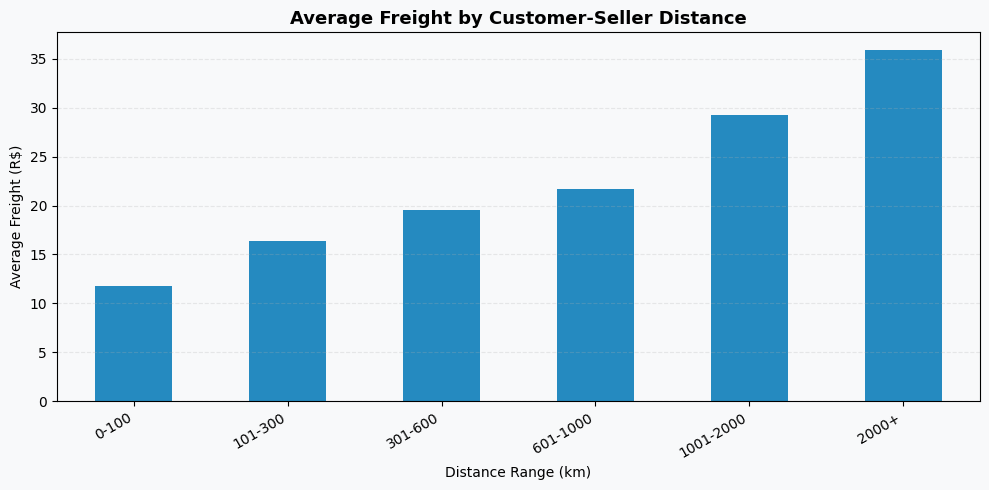

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(FIG_COLOR)
ax.set_facecolor(FIG_COLOR)

distance_analysis["Avg_Freight"].plot(kind="bar", ax=ax, color="#0077B6", alpha=0.85)

ax.set_title("Average Freight by Customer-Seller Distance", fontsize=13, fontweight="bold")
ax.set_xlabel("Distance Range (km)")
ax.set_ylabel("Average Freight (R$)")
ax.grid(axis="y", alpha=0.25, linestyle="--")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("avg_freight_by_distance.png", bbox_inches="tight", dpi=150, facecolor=FIG_COLOR)
plt.show()

## 13. Business Insights & Recommendations

In [24]:
late_avg_review = df[df["Is_Late"] == True]["review_score"].mean()
ontime_avg_review = df[df["Is_Late"] == False]["review_score"].mean()

late_rate = df["Is_Late"].mean() * 100
avg_delivery_duration = df["Delivery_Duration"].mean()
avg_distance = df["customer_seller_distance_km"].mean()

top_category = sales_by_cat.index[0]
top_category_revenue = sales_by_cat.iloc[0]["Total_Revenue"]

reliable_cat = sales_by_cat[sales_by_cat["Num_Orders"] >= 100].copy()

worst_late_category = reliable_cat["Late_Rate_%"].idxmax()
worst_late_rate = reliable_cat["Late_Rate_%"].max()

state_perf_full = (
    df.groupby("customer_state")
    .agg(
        Total_Revenue=("Total_Item_Value", "sum"),
        Num_Orders=("order_id", "nunique"),
        Avg_Review=("review_score", "mean"),
        Late_Rate=("Is_Late", "mean"),
    )
    .sort_values("Total_Revenue", ascending=False)
)

state_perf_full["Late_Rate_%"] = state_perf_full["Late_Rate"] * 100

best_state = state_perf_full.index[0]
best_state_revenue = state_perf_full.iloc[0]["Total_Revenue"]

monthly_perf = (
    df.groupby(["Year", "Month", "Month_Name"])
    .agg(
        Total_Revenue=("Total_Item_Value", "sum"),
        Num_Orders=("order_id", "nunique"),
    )
    .reset_index()
    .sort_values("Total_Revenue", ascending=False)
)

best_month = monthly_perf.iloc[0]["Month_Name"]
best_year = monthly_perf.iloc[0]["Year"]
best_month_revenue = monthly_perf.iloc[0]["Total_Revenue"]

print("=" * 70)
print("BUSINESS INSIGHTS & RECOMMENDATIONS - OLIST")
print("=" * 70)

print(f'''
INSIGHT 1 — DELIVERY PERFORMANCE
   Rata-rata review order terlambat      : {late_avg_review:.2f}
   Rata-rata review order tepat waktu    : {ontime_avg_review:.2f}
   Late delivery rate                    : {late_rate:.1f}%
   Rata-rata durasi pengiriman            : {avg_delivery_duration:.1f} hari

   Rekomendasi:
   Kurangi keterlambatan pengiriman karena order terlambat memiliki review lebih rendah.

INSIGHT 2 — TOP PRODUCT CATEGORY
   Kategori revenue terbesar              : {top_category}
   Total revenue kategori tersebut        : R$ {top_category_revenue:,.0f}

   Rekomendasi:
   Prioritaskan stok, promosi, dan kualitas layanan untuk kategori ini.

INSIGHT 3 — CATEGORY RISK
   Kategori dengan late delivery tertinggi: {worst_late_category}
   Late delivery rate                     : {worst_late_rate:.1f}%

   Rekomendasi:
   Evaluasi seller, fulfillment, dan logistik untuk kategori ini.

INSIGHT 4 — REGIONAL PERFORMANCE
   State customer dengan revenue terbesar : {best_state}
   Total revenue                          : R$ {best_state_revenue:,.0f}

   Rekomendasi:
   Fokuskan strategi marketing dan inventory di wilayah ini.

INSIGHT 5 — DISTANCE ANALYSIS
   Rata-rata jarak customer-seller         : {avg_distance:,.1f} km

   Rekomendasi:
   Pantau hubungan jarak dengan ongkir, durasi pengiriman, dan late delivery.
   Untuk wilayah jauh, optimalkan seller terdekat atau fulfillment hub.

INSIGHT 6 — MONTHLY PERFORMANCE
   Bulan revenue tertinggi                : {best_month} {best_year}
   Total revenue                          : R$ {best_month_revenue:,.0f}

   Rekomendasi:
   Gunakan bulan performa tinggi sebagai acuan campaign dan stock planning.
''')

BUSINESS INSIGHTS & RECOMMENDATIONS - OLIST

INSIGHT 1 — DELIVERY PERFORMANCE
   Rata-rata review order terlambat      : 2.26
   Rata-rata review order tepat waktu    : 4.21
   Late delivery rate                    : 6.6%
   Rata-rata durasi pengiriman            : 12.0 hari

   Rekomendasi:
   Kurangi keterlambatan pengiriman karena order terlambat memiliki review lebih rendah.

INSIGHT 2 — TOP PRODUCT CATEGORY
   Kategori revenue terbesar              : health_beauty
   Total revenue kategori tersebut        : R$ 1,409,051

   Rekomendasi:
   Prioritaskan stok, promosi, dan kualitas layanan untuk kategori ini.

INSIGHT 3 — CATEGORY RISK
   Kategori dengan late delivery tertinggi: audio
   Late delivery rate                     : 11.6%

   Rekomendasi:
   Evaluasi seller, fulfillment, dan logistik untuk kategori ini.

INSIGHT 4 — REGIONAL PERFORMANCE
   State customer dengan revenue terbesar : SP
   Total revenue                          : R$ 5,756,483

   Rekomendasi:
   Fokuskan str

## 14. Output File

Notebook ini menghasilkan beberapa file output:

```text
olist_clean.csv
olist_dashboard_charts.png
heatmap_revenue_by_category.png
avg_freight_by_distance.png
```